# DGP 

## Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats

import doubleml as dml
from sklearn.base import clone
from scipy.linalg import block_diag

np.random.seed(42)

## Hyperparameters

In [2]:
n = int(1e+6) # whole population size

m1 = 5  # number of features affecting only the outcome
m2 = 5  # number of confounders (no treatment heterogeneity)
m3 = 5  # number of confounders with treatment heterogeneity

a1 = 0.15 # baseline conversion probability
a2 = 0.02 # baseline conversion probability effect

p0 = 0.5 # baseline probability of treatment

m = m1 + m2 + m3

## Define Transformations

In [3]:
def transform(x, transformation_type=1):
    if transformation_type == 1:
        res = x
    elif transformation_type == 2:
        res = np.square(x)
    elif transformation_type == 3:
        res = np.power(x, 3)
    elif transformation_type == 4:
        res = np.sin(x)
    elif transformation_type == 5:
        res = np.cos(x)
    elif transformation_type == 6:
        res = np.exp(x)
    elif transformation_type == 7:
        res = np.maximum(x, 0)
    elif transformation_type == 8:
        res = np.log(np.abs(x), where=(np.abs(x)>np.exp(-5.0)), out=-5.0*np.ones_like(x))
    elif transformation_type == 9:
        res = np.sqrt(np.abs(x))
    return res

def generalized_logit(x, alpha=1.0):
    return np.power(1.0 + np.exp(-alpha* x), -1)

In [4]:
# random_transformations
transformation_list = np.random.randint(1, 6, size=m)

transformation_list = 3*[1, 2, 3, 4, 5]
print(transformation_list)

[1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5]


## Generate Covariates

### Continuous Covariates

In [5]:
c = 0.5
covar1 = np.full((m1, m1), np.nan)
for i in range(m1):
    for j in range(m1):
        covar1[i, j] = np.power(c, int(np.abs(i-j)))
covar2 = np.full((m2, m2), np.nan)
for i in range(m2):
    for j in range(m2):
        covar2[i, j] = np.power(c, int(np.abs(i-j)))
covar3 = np.full((m3, m3), np.nan)
for i in range(m3):
    for j in range(m3):
        covar3[i, j] = np.power(c, int(np.abs(i-j)))
# covar = block_diag(covar1, covar2, covar3)
# X = np.random.normal(size=(n, m))
# X = np.random.uniform(low=-1.0, high=1.0, size=(n, m))
# X = stats.multivariate_normal(mean=np.zeros(m), cov=covar).rvs(size=n)


In [6]:
covar = np.full((m, m), np.nan)
for i in range(m):
    for j in range(m):
        covar[i, j] = np.power(c, int(np.abs(i-j)))

X = np.random.multivariate_normal(mean=np.zeros(m), cov=covar, size=n)

In [7]:
Z = np.full_like(X, np.nan)
for col_idx in range(m):
    Z[:, col_idx] = transform(X[:, col_idx], transformation_list[col_idx])
Z = (Z - np.mean(Z, axis=0)) / Z.std(axis=0)

### Categorical Covariates

In [8]:
X_categorical = np.random.choice(["2", "1", "0"], size=(n, 1), p=[0.2, 0.4, 0.4])

df_dummies = pd.get_dummies(pd.DataFrame(X_categorical, columns=["membership_level"]))
X_dummies = df_dummies.values
categorical_feature_names = df_dummies.columns.to_list()

In [9]:
df_dummies

,membership_level_0,membership_level_1,membership_level_2
0,True,False,False
1,True,False,False
2,False,True,False
3,True,False,False
4,False,False,True
...,...,...,...
999995,False,True,False
999996,False,True,False
999997,False,True,False
999998,False,True,False


## Generate Treatment and Outcome

In [10]:
# coefficients

# continuous
coefs_scale_D = 6 / (m1 + m2)
beta_D2 = coefs_scale_D * np.random.uniform(0, 1, size=m2)
beta_D3 = coefs_scale_D * np.random.uniform(0, 1, size=m3)
coefs_scale_Y = 6 / (m1 + m2 + m3)
beta_Y1 = coefs_scale_Y * np.random.uniform(-1, 0, size=m1)
beta_Y2 = coefs_scale_Y * np.random.uniform(-1, 0, size=m2)
beta_Y3 = coefs_scale_Y * np.random.uniform(-1, 0, size=m3)
beta_Y3_D1 = coefs_scale_Y * np.random.uniform(-1, 0, size=m3)

# categorical
categorical_scale_D = 0.3
beta_D_categorical = categorical_scale_D * np.array([-0.5, 1.0, 0.4])
categorical_scale_Y = 0.3
beta_Y_categorical_D1 = categorical_scale_Y * np.array([1.0, -0.1, -0.3])

# error terms
scale = 0.3
epsilon_D = scale * np.random.uniform(-1, 1, size=n)
epsilon_Y = scale * np.random.uniform(-1, 1, size=n)

# define the features subsets for readability
Z1 = Z[:, :m1]
Z2 = Z[:, m1:m1+m2]
Z3 = Z[:, m1+m2:]

alpha = 0.6
logit_p0 = np.log(p0 / (1 - p0))
logit_a1 = np.log(a1 / (1 - a1))
logit_a2 = np.log((a1 + a2) / (1 - (a1 + a2)))

In [11]:
logit_D = logit_p0 + Z2.dot(beta_D2) + Z3.dot(beta_D3) + X_dummies.dot(beta_D_categorical) + epsilon_D
prob_D = np.clip(generalized_logit(logit_D, alpha=alpha), 0.01, 0.99)
D = np.random.binomial(1, prob_D)

print(prob_D.mean())

0.5107816090645191


c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


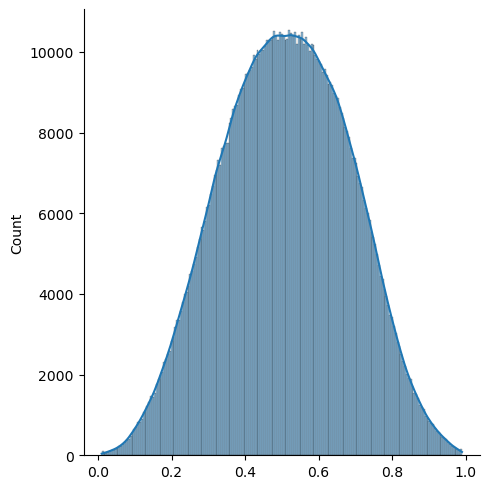

In [12]:
sns.displot(prob_D, kde=True)

c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical

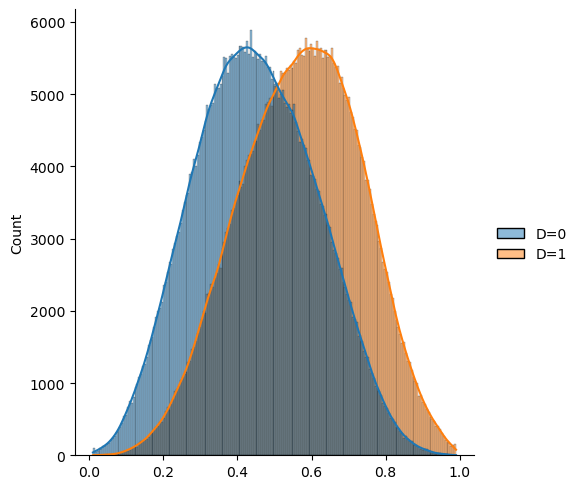

In [13]:
n_min = np.minimum(len(prob_D[D==1]), len(prob_D[D==0]))
df_prob_D = pd.DataFrame(np.column_stack((prob_D[D==0][:n_min], prob_D[D==1][:n_min])), columns=['D=0', 'D=1'])
sns.displot(df_prob_D, kde=True)

In [14]:
basemodel = Z1.dot(beta_Y1) + Z2.dot(beta_Y2) + Z3.dot(beta_Y3) + epsilon_Y
logit_Y_D0 = logit_a1 + basemodel
logit_Y_D1 = logit_a2 + basemodel + Z3.dot(beta_Y3_D1) + X_dummies.dot(beta_Y_categorical_D1)

prob_Y_D0 = np.clip(generalized_logit(logit_Y_D0, alpha=alpha), 0.01, 0.99)
prob_Y_D1 = np.clip(generalized_logit(logit_Y_D1, alpha=alpha), 0.01, 0.99)

prob_Y = prob_Y_D0 * (1 - D) + prob_Y_D1 * D

Y = np.random.binomial(1, prob_Y)

c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\PuD\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical

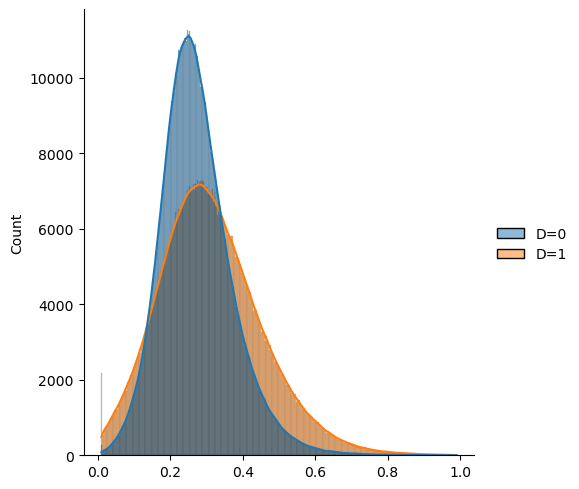

In [15]:
df_prob_Y = pd.DataFrame(np.column_stack((prob_Y_D0, prob_Y_D1)), columns=['D=0', 'D=1'])
sns.displot(df_prob_Y, kde=True)

In [16]:
print(prob_Y.mean())
print(prob_Y_D0.mean())
print(prob_Y_D1.mean())

0.2866073093784663
0.27285094552126216
0.31147764782787124


In [17]:
ind_treat_effect = prob_Y_D1 - prob_Y_D0
print(ind_treat_effect.mean())

0.0386267023066091


In [18]:
ind_treat_effect_treated = prob_Y_D1[D==1] - prob_Y_D0[D==1]
print(ind_treat_effect_treated.mean())

0.026911998092976515


## Bad Controls

In [19]:
small_noise = np.random.normal(scale=0.01, size=n)
bad_control = prob_Y + prob_D + small_noise
X_bad_control = (bad_control - bad_control.mean()) / bad_control.std()

# Binary collider
#X_bad_control = np.where(X_bad_control > 0, 1, 0)

## DataFrame

In [20]:
data = np.column_stack((Y, D, X, X_dummies, X_bad_control, ind_treat_effect))

In [21]:
outcome_name = 'conversion'
treatment_name = 'coupon'
outcome_features = ['X' + str(i) for i in range(m1)]
confounding_features = ['X' + str(i) for i in range(m1, m)] + categorical_feature_names
bad_control_name = 'Z'
ind_treat_effect_name = 'ite'

column_names = [outcome_name, treatment_name] + outcome_features + confounding_features + [bad_control_name, ind_treat_effect_name]
df_large = pd.DataFrame(data=data, columns=column_names)
df_large.head()

,conversion,coupon,X0,X1,X2,X3,X4,X5,X6,X7,...,X10,X11,X12,X13,X14,membership_level_0,membership_level_1,membership_level_2,Z,ite
0,0.0,1.0,-0.911770,-0.310388,-0.354730,0.397070,-1.130727,0.651680,-0.316580,-0.498481,...,0.187715,0.044442,-0.571563,0.684072,-0.505219,1.0,0.0,0.0,1.759539,0.063839
1,0.0,0.0,2.107779,1.350942,0.513782,0.415400,1.116268,1.001325,0.212269,0.998455,...,-0.230834,-0.572155,0.491627,-0.310874,0.253668,1.0,0.0,0.0,0.309403,0.074881
2,0.0,1.0,0.696159,-0.384986,0.465520,1.461894,2.061735,1.313400,2.300369,0.042248,...,-0.699297,0.512477,1.116559,0.376294,0.788950,0.0,1.0,0.0,1.182307,0.048326
3,1.0,1.0,0.707464,0.120454,1.800731,0.261856,0.912950,1.660922,0.329088,0.048371,...,-0.783599,0.424781,0.449760,0.550644,-0.256659,1.0,0.0,0.0,-0.216121,0.076954
4,0.0,1.0,1.008733,0.259872,0.451844,0.277476,2.572872,1.743137,2.218926,1.606350,...,0.925427,-0.808282,-0.567515,0.841674,-0.045244,0.0,0.0,1.0,2.020910,-0.031030


# Causal Analysis

In [22]:
# ATE
treatment_probabiltiy = df_large[treatment_name].mean()
print(treatment_probabiltiy)
ATE = df_large[ind_treat_effect_name].mean()
print(ATE)

0.511161
0.0386267023066091


In [23]:
df_large[['coupon','conversion']].groupby('coupon').mean().diff()

,conversion
coupon,
0.0,NaN
1.0,-0.00871


Get sample to calculate the ATE

In [24]:
subsample_size = 10000
df = df_large.sample(n=subsample_size, random_state=42)
print(df[ind_treat_effect_name].mean())
print(df[df[treatment_name]==1][ind_treat_effect_name].mean())

0.03908395919621666
0.02730992927370012


## Create DAG

In [25]:
import matplotlib.pyplot as plt
import networkx as nx
plt.rcParams['figure.figsize'] = 7., 5
G = nx.DiGraph()

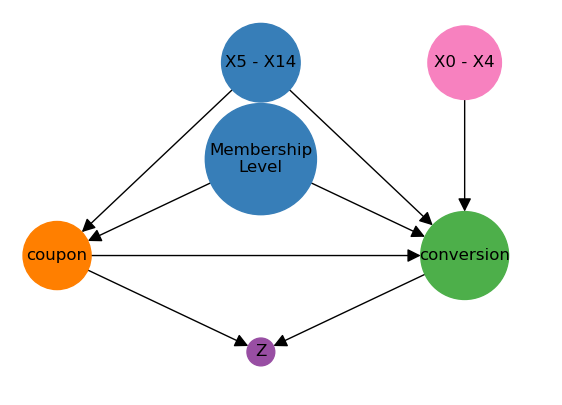

In [26]:
outcome_name = 'conversion'
treatment_name = 'coupon'
cont_confounding_features = f"X{m1} - X{m-1}"
cat_confounding_features = "Membership\nLevel"
outcome_features = f"X0 - X{m1-1}"
bad_control_name = 'Z'

G.add_node(treatment_name)
G.add_node(outcome_name)
G.add_node(cont_confounding_features)
G.add_node(cat_confounding_features)
G.add_node(outcome_features)
G.add_node(bad_control_name)


G.add_edge(treatment_name, outcome_name)
G.add_edge(cont_confounding_features, treatment_name)
G.add_edge(cat_confounding_features, treatment_name)

G.add_edge(outcome_features, outcome_name)
G.add_edge(cont_confounding_features, outcome_name)
G.add_edge(cat_confounding_features, outcome_name)
G.add_edge(treatment_name, bad_control_name)
G.add_edge(outcome_name, bad_control_name)

pos = {treatment_name: (0, 0), 
       outcome_name: (1.5, 0),
       cont_confounding_features: (0.75, 2),
       cat_confounding_features: (0.75, 1),
       outcome_features: (1.5, 2),
       bad_control_name: (0.75, -1)}

the_base_size = 400
colors = {
    'blue':    '#377eb8', 
    'orange':  '#ff7f00',
    'green':   '#4daf4a',
    'pink':    '#f781bf',
    'brown':   '#a65628',
    'purple':  '#984ea3',
    'gray':    '#999999',
    'red':     '#e41a1c',
    'yellow':  '#dede00'
} 

size = [len(v) * the_base_size for v in G.nodes()]
color_map = [colors['orange'], colors['green'], colors['blue'],
             colors['blue'], colors['pink'], colors['purple']]
nx.draw_networkx(G, pos, with_labels=True,
                 node_size=size,
                 node_color=color_map,
                 arrowsize=20,)
                 
plt.axis('off')
axis = plt.gca()
axis.set_xlim([1.1*x for x in axis.get_xlim()])
axis.set_ylim([1.1*y for y in axis.get_ylim()])
plt.show()

In [27]:
# Override names again
outcome_name = 'conversion'
treatment_name = 'coupon'
outcome_features = ['X' + str(i) for i in range(m1)]
confounding_features = ['X' + str(i) for i in range(m1, m)] + categorical_feature_names
bad_control_name = 'Z'
ind_treat_effect_name = 'ite'

## Save Data

In [28]:
path = "../data/"

# df_large.to_csv(path + "uplift_data_population.csv", index=False)
df.to_csv(path + "uplift_data.csv", index=False)


In [29]:
# Random subsample only (faster computations)

df_subsample = df_large.sample(n = 10000)

df_subsample.to_csv(path + "uplift_data_subsample.csv", index = False)

# Save (quasi-)separate data for policy eval
df_subsample.to_csv(path + "uplift_data_policy.csv", index = False)

## Simple comparison and T-Test

Compare to differences in means between treatment and control groups.

In [ ]:
df[['coupon','conversion']].groupby('coupon').mean()

In [ ]:
df[['coupon','conversion']].groupby('coupon').mean().diff()

simple_means = df[['coupon','conversion']].groupby('coupon').mean().diff().values[1,0]
print(simple_means)

T-Test

In [ ]:
treated_sample = df[df['coupon'] == 1]
control_sample = df[df['coupon'] == 0]

In [ ]:
t_test = stats.ttest_ind(treated_sample.loc[:,["conversion"]], control_sample.loc[:,["conversion"]], equal_var=False)
print(t_test)

## Learners

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

ml_g_linear = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
ml_m_linear = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)

ml_g_rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20, max_features=5)
ml_m_rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20, max_features=5)

ml_g_boost = LGBMClassifier(n_estimators=1000, learning_rate=0.005)
ml_m_boost = LGBMClassifier(n_estimators=1000, learning_rate=0.005)

## Basic DoubleML (only confounders)

In [ ]:
dml_data_conf = dml.DoubleMLData(df, outcome_name, treatment_name, x_cols=confounding_features)

In [ ]:
dml_obj_conf_linear = dml.DoubleMLIRM(dml_data_conf, clone(ml_g_linear), clone(ml_m_linear),
                                     n_folds=5,
                                     n_rep=1,
                                     trimming_threshold=0.05,)
dml_obj_conf_linear.fit()

In [ ]:
dml_obj_conf_rf = dml.DoubleMLIRM(dml_data_conf, clone(ml_g_rf), clone(ml_m_rf),
                          n_folds=5,
                          n_rep=1,
                          trimming_threshold=0.05,)
dml_obj_conf_rf.fit()

In [ ]:
dml_obj_conf_boost = dml.DoubleMLIRM(dml_data_conf, clone(ml_g_boost), clone(ml_m_boost),
                          n_folds=5,
                          n_rep=1,
                          trimming_threshold=0.05,)
dml_obj_conf_boost.fit()

In [ ]:
print(dml_obj_conf_linear.summary)
print(dml_obj_conf_rf.summary)
print(dml_obj_conf_boost.summary)

## DoubleML (further controls)

In [ ]:
dml_data = dml.DoubleMLData(df, outcome_name, treatment_name, x_cols=outcome_features + confounding_features)

In [ ]:
dml_obj_linear = dml.DoubleMLIRM(dml_data, clone(ml_g_linear), clone(ml_m_linear),
                                     n_folds=5,
                                     n_rep=1,
                                     trimming_threshold=0.05,)
dml_obj_linear.fit()

In [ ]:
dml_obj_rf = dml.DoubleMLIRM(dml_data, clone(ml_g_rf), clone(ml_m_rf),
                          n_folds=5,
                          n_rep=1,
                          trimming_threshold=0.05,)
dml_obj_rf.fit()

In [ ]:
dml_obj_boost = dml.DoubleMLIRM(dml_data, clone(ml_g_boost), clone(ml_m_boost),
                          n_folds=5,
                          n_rep=1,
                          trimming_threshold=0.05,)
dml_obj_boost.fit()

In [ ]:
print(dml_obj_linear.summary)
print(dml_obj_rf.summary)
print(dml_obj_boost.summary)

## Bad Controls

In [ ]:
dml_data_bad_controls = dml.DoubleMLData(df, outcome_name, treatment_name, x_cols=outcome_features + confounding_features + [bad_control_name])

In [ ]:
dml_obj_linear_bad_controls = dml.DoubleMLIRM(dml_data_bad_controls, clone(ml_g_linear), clone(ml_m_linear),
                                        n_folds=5,
                                        n_rep=1)
dml_obj_linear_bad_controls.fit()

In [ ]:
dml_obj_rf_bad_controls = dml.DoubleMLIRM(dml_data_bad_controls, ml_g_rf, ml_m_rf,
                                        n_folds=5,
                                        n_rep=1)
dml_obj_rf_bad_controls.fit()

In [ ]:
dml_obj_boost_bad_controls = dml.DoubleMLIRM(dml_data_bad_controls, ml_g_boost, ml_m_boost,
                                        n_folds=5,
                                        n_rep=1)
dml_obj_boost_bad_controls.fit()

In [ ]:
print(dml_obj_linear_bad_controls.summary)
print(dml_obj_rf_bad_controls.summary)
print(dml_obj_boost_bad_controls.summary)

## Compare all:

In [ ]:
print("=========== True Values ===========")
print("ATE in Population: ", ATE)
print("ATE in Sample: ", df[ind_treat_effect_name].mean(), "\n")

print("=========== Simple Means and T-Test ===========")
print(f"Estimate: {simple_means:.4f}, p-value: {t_test[1][0]:.4f}", "\n")

print("=========== ATE with only confounding controls ===========")
print(dml_obj_conf_linear.summary)
print(dml_obj_conf_rf.summary)
print(dml_obj_conf_boost.summary, "\n")

print("=========== ATE with all controls ===========")
print(dml_obj_linear.summary)
print(dml_obj_rf.summary)
print(dml_obj_boost.summary, "\n")

print("=========== ATE with bad controls ===========")
print(dml_obj_linear_bad_controls.summary)
print(dml_obj_rf_bad_controls.summary)
print(dml_obj_boost_bad_controls.summary)

## Tune Learner

In [ ]:
par_grids_boost = {'ml_g': {'learning_rate': np.arange(0.05, 0.5, 0.05)},
                   'ml_m': {'learning_rate': np.arange(0.05, 0.5, 0.05)}}

dml_obj_boost_tune = dml.DoubleMLIRM(dml_data, clone(ml_g_boost), clone(ml_m_boost),
                          n_folds=5,
                          n_rep=1,
                          trimming_threshold=0.05)
# Comment out to avoid execution
# dml_obj_boost_tune.tune(param_grids=par_grids_boost)
print(dml_obj_boost_tune.params)
# dml_obj_boost_tune.fit()
print(dml_obj_boost_tune.summary)

## Group Effects

Consider average effect for the groups of the categorical variable.

In [ ]:
for name in categorical_feature_names:
    print(f"{name}: {df_large['ite'][df_dummies[name] == 1].mean()}")

In [ ]:
gate_rf = dml_obj_rf.gate(df[categorical_feature_names] == 1)
print(gate_rf)

In [ ]:
gate_boost = dml_obj_boost.gate(df[categorical_feature_names] == 1)
print(gate_boost)

## CATE

Consider variable $X8$ and $X14$.

In [ ]:
import statsmodels.api as sm
import patsy
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = 15., 7.5

def plot_cate(axis, df_cate, var_name, true_values=None):
    df_cate[var_name] = new_data[var_name]
    axis.plot(df_cate[var_name], df_cate['effect'], label='Estimated Effect')
    axis.fill_between(df_cate[var_name], df_cate['2.5 %'], df_cate['97.5 %'], color='b', alpha=.3, label='Confidence Interval')

    if true_values is not None:
        axis.plot(df_cate[var_name], true_values, color="green", label='True Effect')

    return

In [ ]:
degree = 3
degrees_of_freedom = 6
lower_quantile = 0.2
upper_quantile = 0.8

In [ ]:
var_name = "X5"

True CATE:

In [ ]:
design_matrix_population = patsy.dmatrix(f"bs({var_name}, df={degrees_of_freedom}, degree={degree})", {var_name:df_large[var_name]})
spline_basis_population = pd.DataFrame(design_matrix_population)

cate_population = sm.OLS(df_large['ite'], spline_basis_population).fit()

var_range_population = np.quantile(df_large[var_name], [lower_quantile, upper_quantile])
new_data_population = {var_name: np.linspace(var_range_population[0], var_range_population[1], 100)}
spline_grid_population = pd.DataFrame(patsy.build_design_matrices([design_matrix_population.design_info], new_data_population)[0])

true_values = cate_population.predict(spline_grid_population)

In [ ]:

design_matrix = patsy.dmatrix(f"bs({var_name}, df={degrees_of_freedom}, degree={degree})", {var_name:df[var_name]})
spline_basis = pd.DataFrame(design_matrix)

In [ ]:
cate_rf = dml_obj_rf.cate(spline_basis)
cate_boost = dml_obj_boost.cate(spline_basis)

In [ ]:
var_range = np.quantile(df[var_name], [lower_quantile, upper_quantile])
new_data = {var_name: np.linspace(var_range[0], var_range[1], 100)}
spline_grid = pd.DataFrame(patsy.build_design_matrices([design_matrix.design_info], new_data)[0])

In [ ]:
df_cate_rf = cate_rf.confint(spline_grid, level=0.95, joint=False, n_rep_boot=2000)
df_cate_boost = cate_boost.confint(spline_grid, level=0.95, joint=False, n_rep_boot=2000)

In [ ]:
fig, axis =  plt.subplots(1,2)

plot_cate(axis[0], df_cate_rf, var_name, true_values=true_values)
plot_cate(axis[1], df_cate_boost, var_name, true_values=true_values)

plt.legend()
plt.title('CATE')
plt.xlabel(var_name)
plt.ylabel('Effect and 95%-CI')
plt.show()

In [ ]:
var_name = "X13"

In [ ]:
design_matrix_population = patsy.dmatrix(f"bs({var_name}, df={degrees_of_freedom}, degree={degree})", {var_name:df_large[var_name]})
spline_basis_population = pd.DataFrame(design_matrix_population)

cate_population = sm.OLS(df_large['ite'], spline_basis_population).fit()

var_range_population = np.quantile(df_large[var_name], [lower_quantile, upper_quantile])
new_data_population = {var_name: np.linspace(var_range_population[0], var_range_population[1], 100)}
spline_grid_population = pd.DataFrame(patsy.build_design_matrices([design_matrix_population.design_info], new_data_population)[0])

true_values = cate_population.predict(spline_grid_population)

In [ ]:
design_matrix = patsy.dmatrix(f"bs({var_name}, df={degrees_of_freedom}, degree={degree})", {var_name:df[var_name]})
spline_basis = pd.DataFrame(design_matrix)

In [ ]:
cate_rf = dml_obj_rf.cate(spline_basis)
cate_boost = dml_obj_boost.cate(spline_basis)

In [ ]:
var_range = np.quantile(df[var_name], [lower_quantile, upper_quantile])
new_data = {var_name: np.linspace(var_range[0], var_range[1], 100)}
spline_grid = pd.DataFrame(patsy.build_design_matrices([design_matrix.design_info], new_data)[0])

In [ ]:
df_cate_rf = cate_rf.confint(spline_grid, level=0.95, joint=False, n_rep_boot=2000)
df_cate_boost = cate_boost.confint(spline_grid, level=0.95, joint=False, n_rep_boot=2000)

In [ ]:
fig, axis =  plt.subplots(1,2)

plot_cate(axis[0], df_cate_rf, var_name, true_values=true_values)
plot_cate(axis[1], df_cate_boost, var_name, true_values=true_values)

plt.legend()
plt.title('CATE')
plt.xlabel(var_name)
plt.ylabel('Effect and 95%-CI')
plt.show()

In [ ]:
## Policy Tree

# TODO: evaluate on separate data set (generate hold-out sample and evaluate on that)
